## Basic Functions ## 

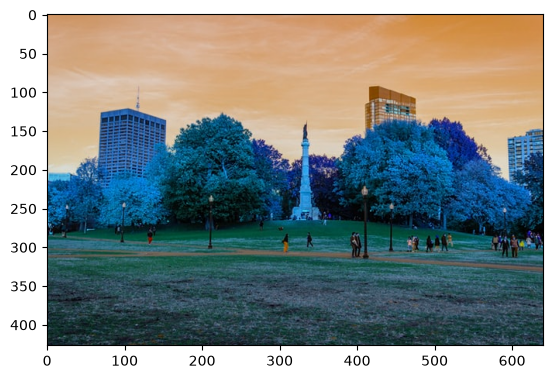

In [2]:
import cv2 as cv
import matplotlib.pyplot as plt
# Read in an image
img = cv.imread('Resources/Photos/park.jpg')
plt.imshow(img)

імпортуємо бібліотеку cv2, через метод cv.imread() визначаємо шлях до зображення, через cv.imshow() визначаємо назву вікна і саму змінну (для відкриття зображень буду використовувати matplotlib)

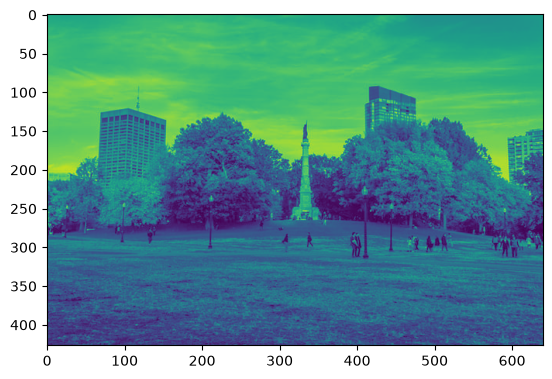

In [3]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
plt.imshow(gray)

через cv.cvtColor() визначаємо змінну і через cv.COLOR_BGR2GRAY міняємо 3 канали на зображені до 1 каналу gray

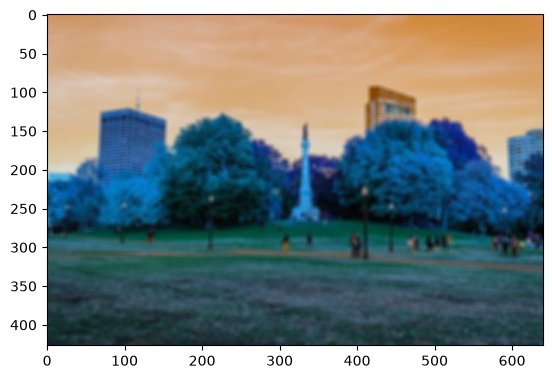

In [4]:
blur = cv.GaussianBlur(img, (7,7), cv.BORDER_DEFAULT)
plt.imshow(blur)

метод cv.GaussianBlur() виконує блюр використовуючи Gaussian filter, cv.BORDER_DEFAULT = 4 використовується для екстраполяції пікселів на зображенні, (7,7) це kernel_size (ядро згортки)
в torchvision цей метод: torchvision.transforms.GaussianBlur() / в albumentations: A.GaussianBlur. різниця в randomness в opencv фіксоване значення, в двох цих це range.

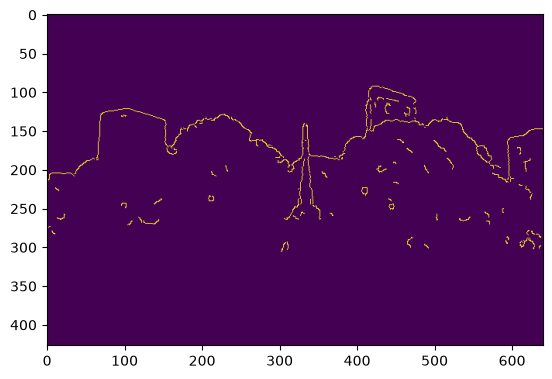

In [5]:
canny = cv.Canny(blur, 125, 175)
plt.imshow(canny)

через cv.Canny() можемо визначати края обʼєктів на зображенні, 125 і 175 це thresholds (низкий поріг (для слабких звʼязків) і високий (для сильних звʼязків))

в torchvision & albumentations: логіка алгоритму така сама, різниця тільки в можливості hardware і підтримки батчів

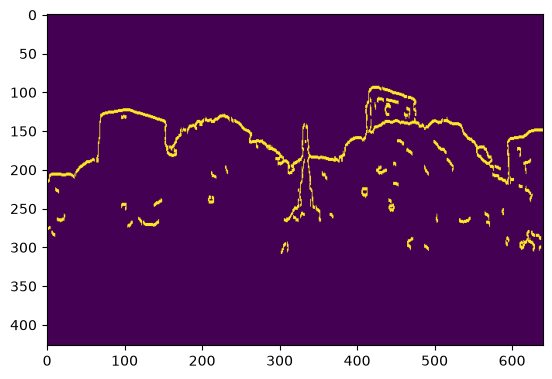

In [6]:
dilated = cv.dilate(canny, (7,7), iterations=3)
plt.imshow(dilated)

через метод cv.dilate() ми можемо розширювати білі регіони зображення (потовщуємо), визначаємо kernel_size, iterations=3 означає кількість ітерацій операції.

torchvision & albumentations: random augmentation pipeline / batch tensor, коли в opencv це просто зображення.

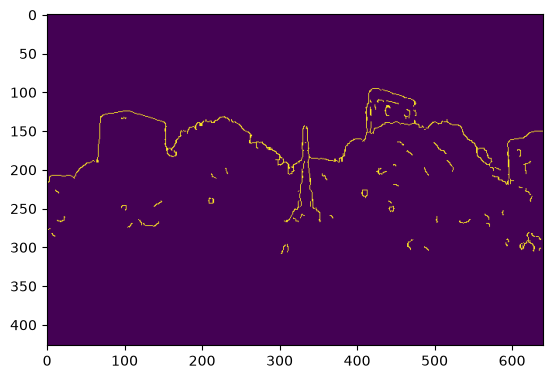

In [7]:
eroded = cv.erode(dilated, (7,7), iterations=3)
plt.imshow(eroded)

cv.erode() навпаки зменшує білі регіони на зображенні.

torchvision & albumentations: таке саме як і для cv.dilate()

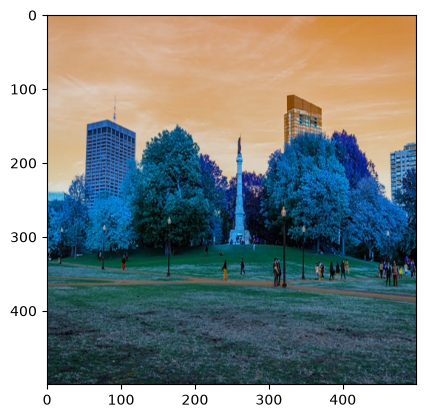

In [8]:
resized = cv.resize(img, (500,500), interpolation=cv.INTER_CUBIC)
plt.imshow(resized)

метод cv.resize() змінює dimensions для вхідного зображення, interpolation в цьому методі із значенням INTER_CUBIC означає метод інтерполяції для зображення - INTER_CUBIC для повільнішої, але якість буде найкраща.

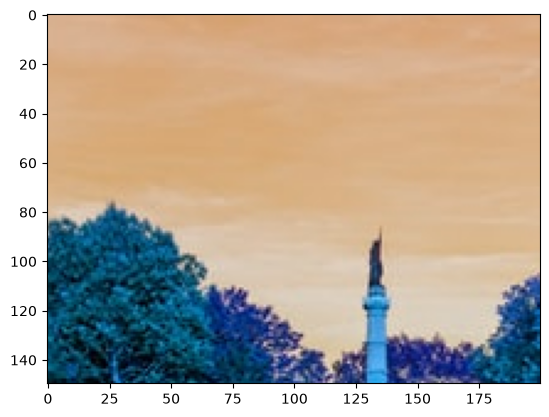

In [9]:
cropped = img[50:200, 200:400]
plt.imshow(cropped)

numpy синтаксис для слайсінгу зображень, де перше значення це вертикальне, а друге це горизонтальне.

## Contours ##

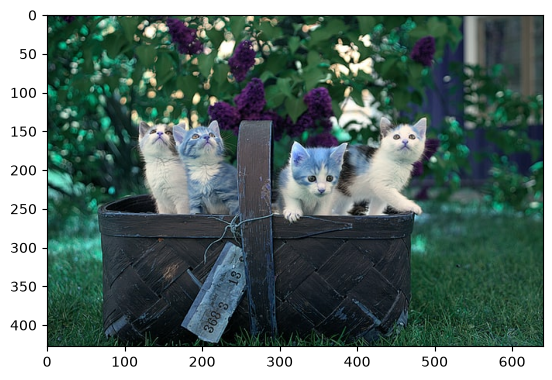

In [10]:
img = cv.imread('Resources/Photos/cats.jpg')
plt.imshow(img)

просто відкриваємо зображення за його шляхом.

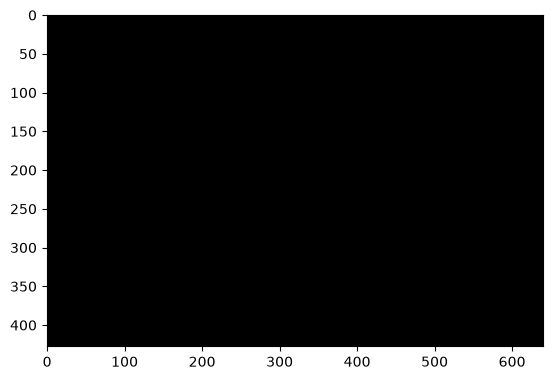

In [11]:
import numpy as np
blank = np.zeros(img.shape, dtype='uint8')
plt.imshow(blank)

через numpy метод для створення масиву з нулів отримуємо "пусте" зображення (суцільно чорне)

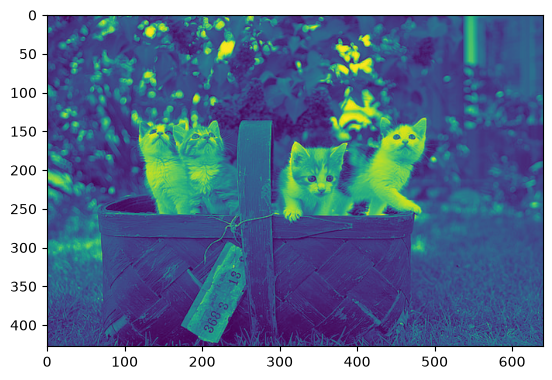

In [12]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
plt.imshow(gray)

конвертуємо зображення в gray вигляд

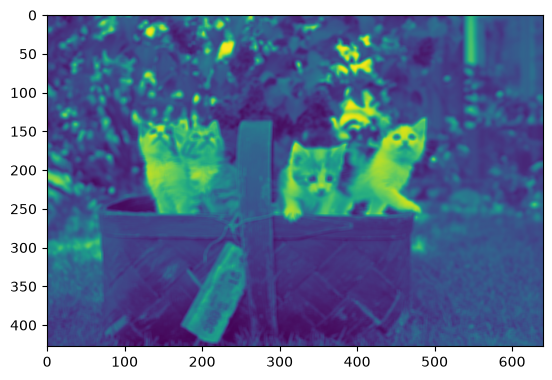

In [13]:
blur = cv.GaussianBlur(gray, (5,5), cv.BORDER_DEFAULT)
plt.imshow(blur)

повторюємо метод для накладання на зображення гаусівського блюру

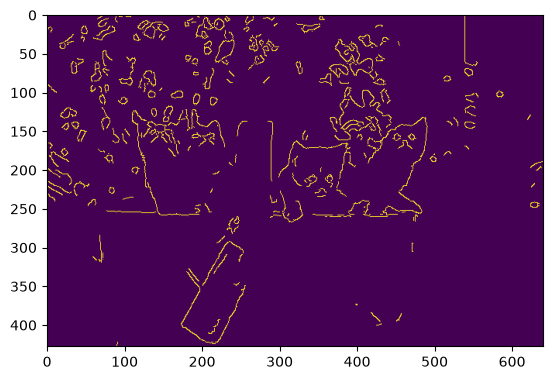

In [14]:
canny = cv.Canny(blur, 125, 175)
plt.imshow(canny)

наведення країв обʼєктів на зображенні білим кольором

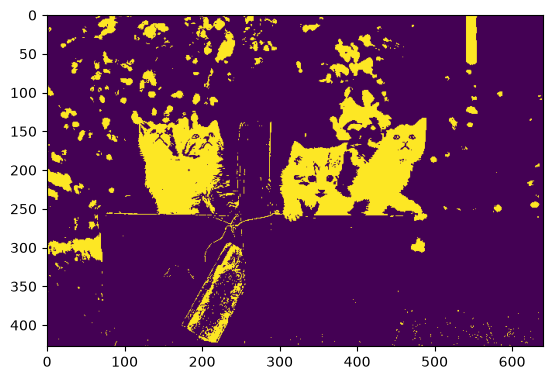

In [15]:
ret, thresh = cv.threshold(gray, 125, 255, cv.THRESH_BINARY)
plt.imshow(thresh)

метод cv.threshold() конвертує зображення до black/white формату (THRESH_BINARY), з певними значеннями для нижнього і верхнього порогів 

380 contour(s) found!


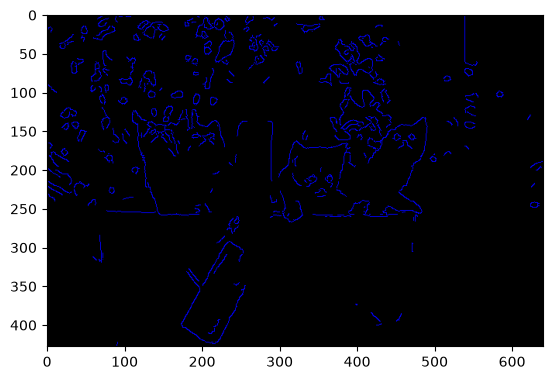

In [16]:
contours, hierarchies = cv.findContours(canny, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)
print(f'{len(contours)} contour(s) found!')

cv.drawContours(blank, contours, -1, (0,0,255), 1)
plt.imshow(blank)

метод cv.findCountours() знаходить контури з binary/edge зображень, cv.RETR_LIST означає повернення усіх контурів зображення, cv.CHAIN_APPROX_SIMPLE стискає контури (прибирає залишкові точки). метод cv.drawContours() малює на "пустому" зображенні до цього контури (список контурів, "contours"), "-1" означає намалювати усі контури, або можна написати інший індекс для окремого контура. в скобках це палітра кольорів від 0 до 255 в BGR форматі (але через те, що я відмальовую зображення через matplotlib, то воно презентує це у форматі RGB)

## Draw ##

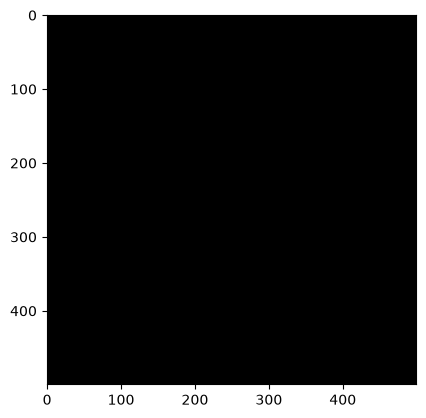

In [19]:
blank = np.zeros((500,500,3), dtype='uint8')
plt.imshow(blank)

створюємо масив з нулів і виводимо через imshow()

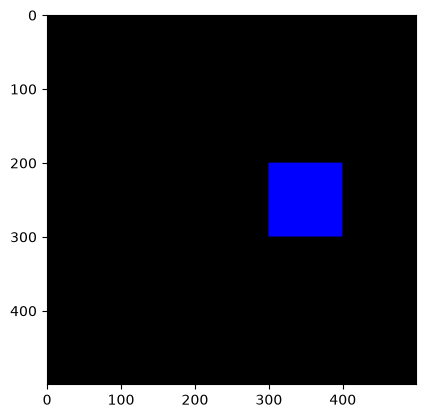

In [20]:
blank[200:300, 300:400] = 0,0,255
plt.imshow(blank)

через синтаксис слайсінгу визначаємо квадрат і колір для нього у форматі BGR

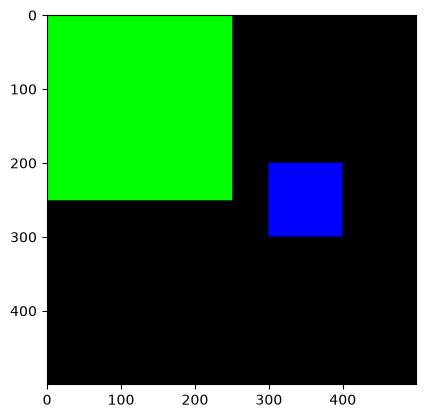

In [21]:
cv.rectangle(blank, (0,0), (blank.shape[1]//2, blank.shape[0]//2), (0,255,0), thickness=-1)
plt.imshow(blank)

через метод cv.rectangle() можемо малювати квадрат, де перше значення в методі це координати верхньої точки, а друге це координати нижньої точки, далі колір і thickness=-1 означає, що квадрат повинен бути заповненим.

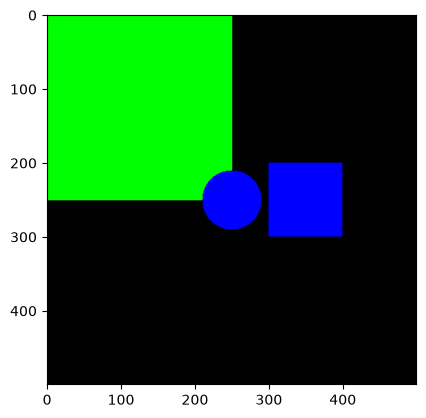

In [22]:
cv.circle(blank, (blank.shape[1]//2, blank.shape[0]//2), 40, (0,0,255), thickness=-1)
plt.imshow(blank)

через метод cv.circle() додаємо до нашого зображення коло: значення координат центру кола, далі радіус, колір і thickness

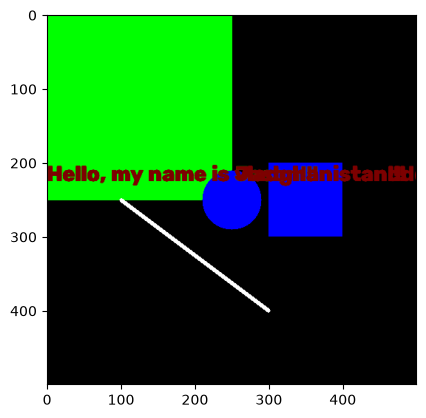

In [32]:
cv.line(blank, (100,250), (300,400), (255,255,255), thickness=3)
plt.imshow(blank)

через метод cv.line() можна на зображенні додати лінію через дві координати та колір і thickness.

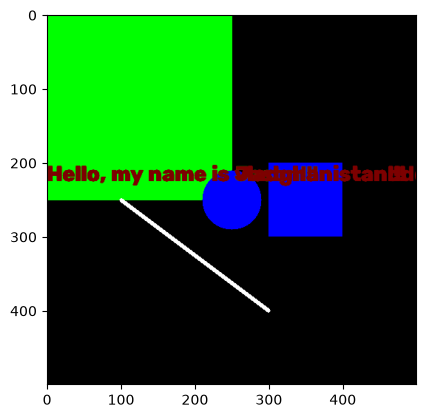

In [33]:
cv.putText(blank, 'Hello, my name is vladghanistan!!!', (0,225), cv.FONT_HERSHEY_TRIPLEX, 1.0, (125,0,0), 2)
plt.imshow(blank)

через метод cv.putText() можна додавати текст на зображення: string який потрібно вивести, координати, fontFace: cv.FONT_HERSHEY_TRIPLEX, fontScale 1.0, колір і товщина '2'.